# 03 · Baseline XGBoost
## Tesis UBA 2026 — LLMs vs. ML Clásico para Credit Scoring

Este notebook **entrena XGBoost paso a paso**, mostrando todo el proceso. La misma lógica
está encapsulada en `scripts/03_baseline_xgboost.py` como `train_xgboost(...)` (reutilizable
como nodo de pipeline); acá usamos sus funciones componentes para que el entrenamiento sea
visible.

### ¿Por qué XGBoost es el *baseline*?
Lessmann et al. (2015) compararon 41 clasificadores sobre 8 datasets de credit scoring y el
*gradient boosting* domina consistentemente la clasificación tabular. Es el estado del arte
empírico contra el cual debe medirse el LLM.

### Diseño
1. **Split temporal** train/val/test por la columna `set` (respeta `fecha_desembolso`).
   No usamos k-fold barajado: mezclaría cohortes 2022/2024 → *data leakage*.
2. **Optuna** (50 *trials*) optimiza hiperparámetros maximizando AUC en validación.
3. Reportamos **AUC en train, val y test por separado**: el gap train→test es el indicador
   honesto de sobreajuste.

In [1]:
import importlib.util
from pathlib import Path

import pandas as pd
import xgboost as xgb
from IPython.display import Image


def _find_base() -> Path:
    base = Path.cwd()
    while not (base / "scripts").exists() and base != base.parent:
        base = base.parent
    return base


BASE = _find_base()


def load_script(filename: str):
    path = BASE / "scripts" / filename
    spec = importlib.util.spec_from_file_location("s_03", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


m03 = load_script("03_baseline_xgboost.py")

/Users/federicomoreno/.venvs/new_tesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paso 1 — Splits temporales
`load_splits` separa train/val/test por la columna `set` y devuelve X/y por conjunto.

In [2]:
splits = m03.load_splits(str(BASE / "data" / "dataset_tesis.csv"))
pd.DataFrame({
    s: {"n": len(splits[s]["y"]), "default_rate": round(splits[s]["y"].mean(), 3)}
    for s in ("train", "val", "test")
}).T

,n,default_rate
train,4364.0,0.486
val,492.0,0.494
test,495.0,0.491


In [3]:
print(f"Nº de features: {len(splits['features'])}")

Nº de features: 94


## Paso 2 — Búsqueda de hiperparámetros con Optuna
El objetivo maximiza el AUC de **validación** con *early stopping*. Train siempre precede a
val (sin mezclar fechas). Se corren 50 *trials* (TPE, semilla fija).

In [4]:
best_params = m03.tune_hyperparams(splits)
best_params

{'n_estimators': 374,
 'max_depth': 4,
 'learning_rate': 0.10576330630597151,
 'subsample': 0.9993986750197684,
 'colsample_bytree': 0.8185863822850529,
 'min_child_weight': 4,
 'reg_alpha': 0.0005822237066801763,
 'reg_lambda': 0.0844242173739329,
 'objective': 'binary:logistic',
 'eval_metric': 'auc',
 'random_state': 42,
 'n_jobs': -1}

## Paso 3 — Entrenamiento del modelo final
Con los mejores hiperparámetros, entrenamos sobre train usando val para *early stopping*.
Este es el `fit` real del baseline:

In [5]:
model = xgb.XGBClassifier(**best_params, early_stopping_rounds=30, verbosity=0)
model.fit(
    splits["train"]["X"], splits["train"]["y"],
    eval_set=[(splits["val"]["X"], splits["val"]["y"])],
    verbose=False,
)
print(f"Modelo entrenado — {model.n_estimators} árboles, profundidad máx {model.max_depth}")

Modelo entrenado — 374 árboles, profundidad máx 4


## Paso 4 — Evaluación por split
Calculamos AUC/Gini/KS/Brier en train, val y test. El **AUC de test** es la métrica honesta
y principal.

In [6]:
probs = {s: model.predict_proba(splits[s]["X"])[:, 1] for s in ("train", "val", "test")}
metrics = {s: m03.credit_metrics(splits[s]["y"], probs[s]) for s in ("train", "val", "test")}
tabla = pd.DataFrame({s: {k: round(v, 4) for k, v in metrics[s].items()}
                      for s in ("train", "val", "test")}).T
tabla

,AUC,Gini,KS,Brier,PR-AUC
train,0.9481,0.8962,0.7338,0.0948,0.9514
val,0.8981,0.7963,0.7213,0.4842,0.9259
test,0.8201,0.6402,0.5315,0.4988,0.8367


In [7]:
gap = round(metrics["train"]["AUC"] - metrics["test"]["AUC"], 4)
print(f"Gap de sobreajuste (AUC train − test): {gap}")

Gap de sobreajuste (AUC train − test): 0.128


## Curva ROC (validación vs. test)
Figura generada por el script al correr `train_xgboost`.

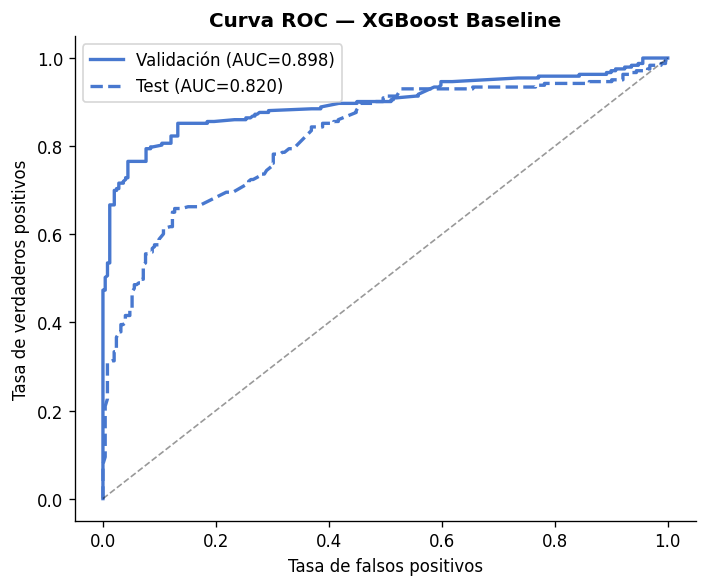

In [8]:
Image(filename=str(BASE / "figures" / "11_roc_xgboost.png"))

**Lectura.** XGBoost alcanza un AUC de test sólido y creíble para credit scoring en
microfinanzas. Este número es el *techo* clásico contra el que comparamos el LLM en los
notebooks 06b (zero-shot) y 08 (few-shot).

> El script `03_baseline_xgboost.py` envuelve exactamente estos pasos en `train_xgboost()`,
> que además persiste el modelo (`.json`/`.pkl`), el JSON de métricas y las figuras
> (ROC, KS, calibración, SHAP). Acá los mostramos desagregados para transparencia.